# Week 4, Day 2

## Task 1: Problem Definition & Success Metrics

* **Business Goal:** Efficiently target outreach (calls/mailers) for a premium financial product.
* **Target Class:** `income > 50K` (encoded as `1`); all others `0`.
* **Primary Metric: Precision.** Every contact costs money. We prioritize precision to avoid cash-burning false positives (contacting unqualified leads). Missed high earners (false negatives) are acceptable opportunity costs.
* **Secondary Metric: ROC AUC.** Used as a threshold-independent check of model quality. F1 is tracked but ignored for optimization, as it incorrectly treats false positives and false negatives as equally costly.
* **Stakeholder Bottom Line:** Maximize the success rate of the outreach budget. It is better to occasionally miss a good lead than consistently pay to contact bad ones.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
import os

os.makedirs('Models', exist_ok=True)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

RANDOM_STATE = 42
pd.set_option('display.max_columns', 50)
sns.set_theme(style="whitegrid")


In [ ]:
column_names = [
"age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

dataset = fetch_openml('adult', version=2, as_frame=True)
df = dataset.frame

df.replace('?', np.nan, inplace=True)

print("Shape:", df.shape)
df.head()

Shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
# uncomment the line below if data is raw because openml parser already converts '?' to NaN when it loads the data
# df = df.replace('?', np.nan)

df.rename(columns={'class': 'income'}, inplace=True)

df["income"] = df["income"].str.strip().str.rstrip(".")
df["target"] = (df["income"] == ">50K").astype(int)

df[["income", "target"]].drop_duplicates()
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,target
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K,0


In [ ]:
# Column types and missingness
print(df.dtypes)
missing = df.isna().sum()
print(missing,"\n")
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)
print()
print(f"Total missing cells: {df.isna().sum().sum()} "
      f"({df.isna().sum().sum() / df.size} of all cells)")


age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
income              object
target               int64
dtype: object
age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
target               0
dtype: int64 

Columns with missing values:
occupation        2809
workclass         2799
native-country     857
dtype: int64

Total missing cells: 6465 (0.83% of all cells)


In [ ]:
# Numeric data
numeric_cols = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
df[numeric_cols].describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
for col in ["workclass", "education", "marital-status", "occupation", "sex", "race"]:
    print(f"{col} ")
    print(df[col].value_counts(dropna=False).head(8))
    print()


 --- workclass 
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
NaN                  2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Name: count, dtype: int64

 --- education 
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
Name: count, dtype: int64

 --- marital-status 
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

 --- occupation 
occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
NaN                 

In [ ]:
# Class base rate
base_rate = df["target"].mean()
class_counts = df["target"].value_counts().rename({0: "<=50K", 1: ">50K"})
print(class_counts)
print(f"\nBase rate (positive class share): {base_rate:.2%}")


target
<=50K    37155
>50K     11687
Name: count, dtype: int64

Base rate (positive class share): 23.93%


In [ ]:
# 80% train+dev / 20% hold-out test, stratified on the target
train_dev_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df["target"], random_state=RANDOM_STATE
)

# further opt-split: carve a dev set out of the remaining 80%
train_df, dev_df = train_test_split(
    train_dev_df, test_size=0.125, stratify=train_dev_df["target"], random_state=RANDOM_STATE
) # will be used later , reserved for tommorow

print(f"Train size: {len(train_df)}  ({len(train_df)/len(df):.1%} of full data)")
print(f"Dev size:   {len(dev_df)}   ({len(dev_df)/len(df):.1%} of full data)")
print(f"Test size:  {len(test_df)}  ({len(test_df)/len(df):.1%} of full data)")
print()
print("Class balance check (share of positives in each split):")
for name, part in [("Full data", df), ("Train", train_df), ("Dev", dev_df), ("Test (hold-out)", test_df)]:
    print(f"  {name:18s}: {part['target'].mean():.2%}")


Train size: 34188  (70.0% of full data)
Dev size:   4885   (10.0% of full data)
Test size:  9769  (20.0% of full data)

Class balance check (share of positives in each split):
  Full data         : 23.93%
  Train             : 23.93%
  Dev               : 23.93%
  Test (hold-out)   : 23.93%


In [ ]:
# Majority-class predictor
majority_class = train_df["target"].mode()[0]
print(f"Majority class in training data: {majority_class} "
      f"({'<=50K' if majority_class == 0 else '>50K'})")

y_test = test_df["target"].values
y_pred_majority = np.full_like(y_test, fill_value=majority_class)
# Probability
y_score_majority = y_pred_majority.astype(float)


Majority class in training data: 0 (<=50K)


In [ ]:
# Single-feature rule
# Rule: predict True if education-num >= 13 OR capital-gain > 0
def rule_predict(frame):
    return ((frame["education-num"] >= 13) | (frame["capital-gain"] > 0)).astype(int)

y_pred_rule = rule_predict(test_df).values
y_score_rule = (
    (test_df["education-num"] / test_df["education-num"].max()) * 0.5
    + (test_df["capital-gain"] > 0).astype(float) * 0.5
).values


In [ ]:
def evaluate(y_true, y_pred, y_score, name):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
    }

results = [
    evaluate(y_test, y_pred_majority, y_score_majority, "Majority-class"),
    evaluate(y_test, y_pred_rule, y_score_rule, "Rule-based (education-num>=13 OR capital-gain>0)"),
]
results_df = pd.DataFrame(results).set_index("model").round(4)
results_df


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Majority-class,0.7607,0.0000,0.0000,0.0000,0.5000,0.2393
Rule-based (education-num>=13 OR capital-gain>0),0.7520,0.4852,0.5967,0.5352,0.7493,0.5079


In [ ]:
single_rule_f1 = results_df.loc["Rule-based (education-num>=13 OR capital-gain>0)", "f1"]
single_rule_auc = results_df.loc["Rule-based (education-num>=13 OR capital-gain>0)", "roc_auc"]
majority_f1 = results_df.loc["Majority-class", "f1"]
majority_acc = results_df.loc["Majority-class", "accuracy"]
print(single_rule_f1)
print(single_rule_auc)
print(majority_f1)
print(majority_acc)

0.5352
0.7493
0.0
0.7607


## Importing Library Classes

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

## Task 1: Preprocessing Plan & Implementation

* **Feature Selection:**
* **Numeric:** `age`, `education-num`, `capital-gain`, `capital-loss`, `hours-per-week`.
* **Categorical:** `workclass`, `marital-status`, `occupation`, `relationship`, `race`, `sex`, `native-country`.
* **Removed:** The `education` text column (redundant with `education-num`) and target labels (`income`).


* **Numeric Preprocessing (Median Imputation):** We use the median instead of the mean because variables like `capital-gain` are highly right-skewed; the median resists outliers. Complex iterative imputations were rejected as unnecessary, especially since these specific numeric columns lack missing values.
* **Categorical Preprocessing (One-Hot Encoding):** Applied because these variables lack a natural order, which makes ordinal encoding misleading for linear models. We use `handle_unknown='ignore'` to safely process rare, unseen categories (like rare countries) during testing. Target encoding was rejected to prevent data leakage.
* **Handling Missing Data:** Categorical NaNs are currently filled using the most frequent value (mode) for simplicity alongside one-hot encoding. Creating an explicit `"Missing"` category to capture "unanswered" as a distinct, learnable signal is planned for a later iteration.

#### Defining Numeric and Categorical Columns

In [ ]:
categorical_cols = ["workclass", "marital-status", "occupation", "relationship",
                         "race", "sex", "native-country"]

# combined feautres
feature_cols = numeric_cols + categorical_cols

# No need to replace "?" -> NaN, it's already done yesterday.

# Train and test data
X_train, y_train = train_df[feature_cols], train_df["target"]
X_dev,   y_dev = dev_df[feature_cols],   dev_df["target"]
X_test_feature = test_df[feature_cols]

#### Building a sklearn ColumnTransformer pipeline

In [ ]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
        ('num', numeric_pipeline, numeric_cols),
        ('cat', categorical_pipeline, categorical_cols)
])


## Task 2: Train Two Supervised Models (in Pipelines)

Fitting both on the training set only. Did not touch the hold-out test set here.

In [ ]:
# Model 1
logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE))
    # lbfgs use L2 refulariztion
    ])
logistic_pipeline.fit(X_train, y_train)

# Model 2
decision_tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE))
])
decision_tree_pipeline.fit(X_train, y_train)

print("Both models fitted while holding out test data for evaluation")

Both models fitted while holding out test data for evaluation


## Task 3: Evaluating on Hold-Out Test (Multiple Metrics)

In [ ]:
y_pred_log_reg = logistic_pipeline.predict(X_test_feature)
y_score_log_reg = logistic_pipeline.predict_proba(X_test_feature)[:, 1]

y_pred_dec_tree = decision_tree_pipeline.predict(X_test_feature)
y_score_dec_tree = decision_tree_pipeline.predict_proba(X_test_feature)[:, 1]

result_2 = [
    evaluate(y_test, y_pred_log_reg, y_score_log_reg, "LogisticRegression"),
    evaluate(y_test, y_pred_dec_tree, y_score_dec_tree, "DescisionTree")
]

result_2_df = pd.DataFrame(result_2).set_index("model").round(4)

# comaparison from simple models
comparison_df = pd.concat([results_df, result_2_df])

display(comparison_df)


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Majority-class,0.7607,0.0000,0.0000,0.0000,0.5000,0.2393
Rule-based (education-num>=13 OR capital-gain>0),0.7520,0.4852,0.5967,0.5352,0.7493,0.5079
LogisticRegression,0.8528,0.7399,0.5937,0.6588,0.9032,0.7607
DescisionTree,0.8538,0.7658,0.5607,0.6474,0.8823,0.6981


#### Visualization

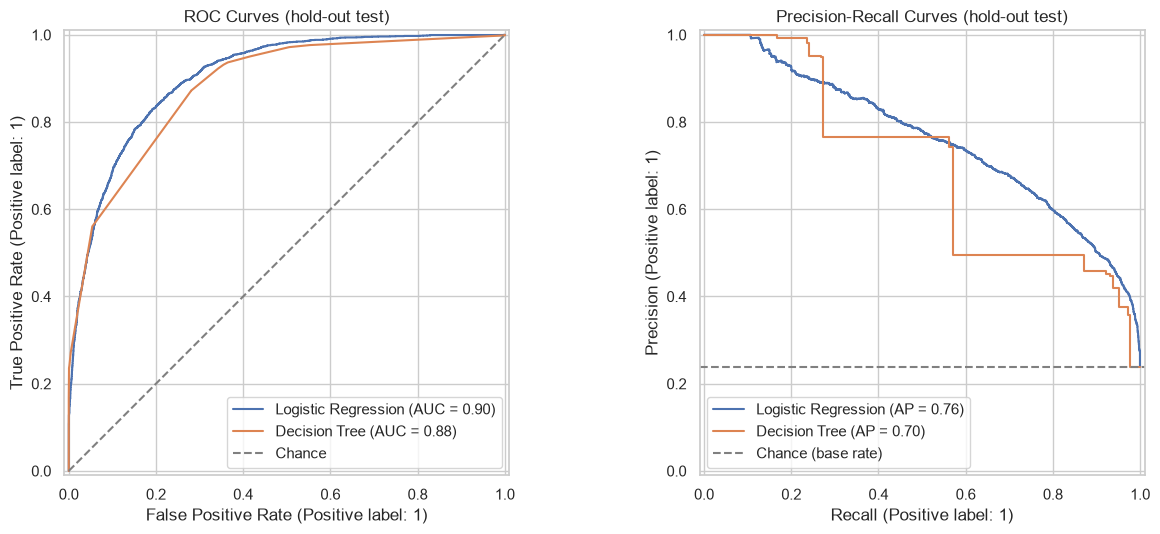

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

RocCurveDisplay.from_predictions(y_test, y_score_log_reg, name="Logistic Regression", ax=axes[0])
RocCurveDisplay.from_predictions(y_test, y_score_dec_tree, name="Decision Tree", ax=axes[0])
axes[0].plot([0, 1], [0, 1], linestyle="--", label="Chance")
axes[0].set_title("ROC Curves on hold-out data")
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, y_score_log_reg, name="Logistic Regression", ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_test, y_score_dec_tree, name="Decision Tree", ax=axes[1])
axes[1].axhline(y_test.mean(), linestyle="--", label="Chance base")
axes[1].set_title("Precision-Recall Curves on hold-out data")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Insights: ROC & PR Curves and Error-Type Discussion (Hold-Out Test)

- ROC AUC: Logistic Regression = 0.9032, Decision Tree = 0.8823. Both are good rankers, but LogReg has the edge on overall ordering.
- At the default 0.5 threshold, Decision Tree precision = 0.7658 vs Logistic Regression precision = 0.7399. Since precision is our primary metric, this makes the Tree slightly more attractive on the actual contact decision, even though LogReg is stronger on ROC AUC and PR AUC.
- PR AUC: Logistic Regression = 0.7607, Decision Tree = 0.6981, versus the base-rate chance floor of ~0.2393. This confirms both models add useful signal beyond the class base rate, with LogReg achieving the better threshold-independent tradeoff.
- Tree's PR curve is still jagged; it only produces a limited set of distinct probability scores from its leaves. LogReg's curve is smoother because it outputs continuous probabilities.
- Both models reach very high precision at low recall, which is consistent with the precision-first business goal of contacting only the most likely high earners.


#### Confusion Matrix

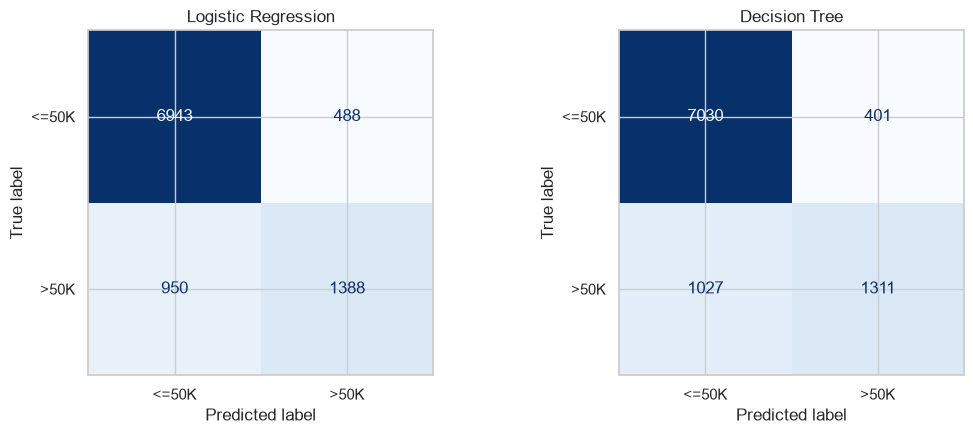

In [ ]:
confusion_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
confusion_matrix_dec_tree = confusion_matrix(y_test, y_pred_dec_tree)

# Confusion matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

confusion_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
ConfusionMatrixDisplay(confusion_matrix_log_reg, display_labels=["<=50K", ">50K"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression")

confusion_matrix_dec_tree = confusion_matrix(y_test, y_pred_dec_tree)
ConfusionMatrixDisplay(confusion_matrix_dec_tree, display_labels=["<=50K", ">50K"]).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Decision Tree")

plt.tight_layout()
plt.show()

Error-type discussion. At the default 0.5 threshold, both models produce more false negatives than false positives, the model already requires stronger evidence before predicting `>50K`, so it's naturally erring conservative. Given Day 1 logic (false positives = wasted outreach = the costly error), this is the right direction: we're already leaning toward precision without touching the threshold.

- If recall matters more later: lower the threshold below 0.5, trading precision back for recall (walking left on the PR curve).
- If precision should be pushed even further: raise the threshold above 0.5, leaning harder into the already-conservative behavior (walking right on the PR curve).


## Task 4: Interpretability Check

Logistic Regression:

In [ ]:
feature_names = logistic_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefs = logistic_pipeline.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs}).sort_values(
    "coefficient", ascending=False
)

top_positive = coef_df.head(10).reset_index(drop=True)
top_negative = coef_df.tail(10).sort_values("coefficient").reset_index(drop=True)

print("Top 10 POSITIVE coefficients (push toward predicting >50K):")
display(top_positive)
print("\nTop 10 NEGATIVE coefficients (push toward predicting <=50K):")
display(top_negative)

Top 10 POSITIVE coefficients (push toward predicting >50K):


,feature,coefficient
0,num__capital-gain,2.218460
1,cat__marital-status_Married-civ-spouse,1.596623
2,cat__marital-status_Married-AF-spouse,1.274892
3,cat__native-country_Ireland,0.911378
4,cat__native-country_France,0.848947
5,cat__occupation_Exec-managerial,0.809476
6,cat__relationship_Wife,0.806245
7,num__education-num,0.769411
8,cat__native-country_England,0.755397
9,cat__native-country_Iran,0.668031



Top 10 NEGATIVE coefficients (push toward predicting <=50K):


,feature,coefficient
0,cat__occupation_Priv-house-serv,-1.353548
1,cat__marital-status_Never-married,-1.190421
2,cat__native-country_Columbia,-1.090962
3,cat__native-country_South,-0.978931
4,cat__relationship_Other-relative,-0.919120
5,cat__occupation_Farming-fishing,-0.916071
6,cat__sex_Female,-0.901089
7,cat__occupation_Other-service,-0.834307
8,cat__marital-status_Separated,-0.802523
9,cat__relationship_Own-child,-0.791138


Decision Tree: tree depth and train vs. test score (to check for overfitting).

In [ ]:
tree_clf = decision_tree_pipeline.named_steps["classifier"]
train_score = decision_tree_pipeline.score(X_train, y_train)
test_score = decision_tree_pipeline.score(X_test_feature, y_test)

print(f"Tree depth: {tree_clf.get_depth()}")
print(f"Tree leaves: {tree_clf.get_n_leaves()}")
print(f"Train accuracy: {train_score}")
print(f"Test accuracy:  {test_score}")
print(f"Train - Test gap: {train_score - test_score}")

Tree depth: 5
Tree leaves: 29
Train accuracy: 0.8519
Test accuracy:  0.8538
Train - Test gap: -0.0019


### Interpretability Check

Logistic Regression coefficients
- capital-gain is the single strongest predictor of >50K (coef ≈ 2.22), consistent with Day 1/2's earlier findings.
- Marital status (Married-civ-spouse +1.60, Married-AF-spouse +1.27) and relationship_Wife (+0.81) form a coherent positive signal around partnered/dual-income households.
- education-num (+0.77) and occupation_Exec-managerial (+0.81) confirm that schooling and senior managerial roles matter, as expected.
- Caution: several native-country coefficients (Ireland +0.91, France +0.85, Canada +0.46, and others) are likely small-sample artifacts. Rare countries have few examples, so a handful of high earners can swing those weights; better not over-interpret them.
- Fairness flag: sex_Female is strongly negative (-0.90). This reflects patterns in the training data, not a causal claim, and should be called out before using the model for outreach targeting.
- Negative coefficients otherwise line up intuitively: Never-married, Priv-house-serv, Farming-fishing, Other-service, relationship_Other-relative, and relationship_Own-child.

Decision Tree: overfitting check
- Capped at depth 5 in the current pipeline.
- Train accuracy = 0.8519, test accuracy = 0.8538, giving a gap of about 0.0020.
- This tiny gap indicates the depth cap is helping prevent overfitting and the tree is generalizing well rather than memorizing the training set.

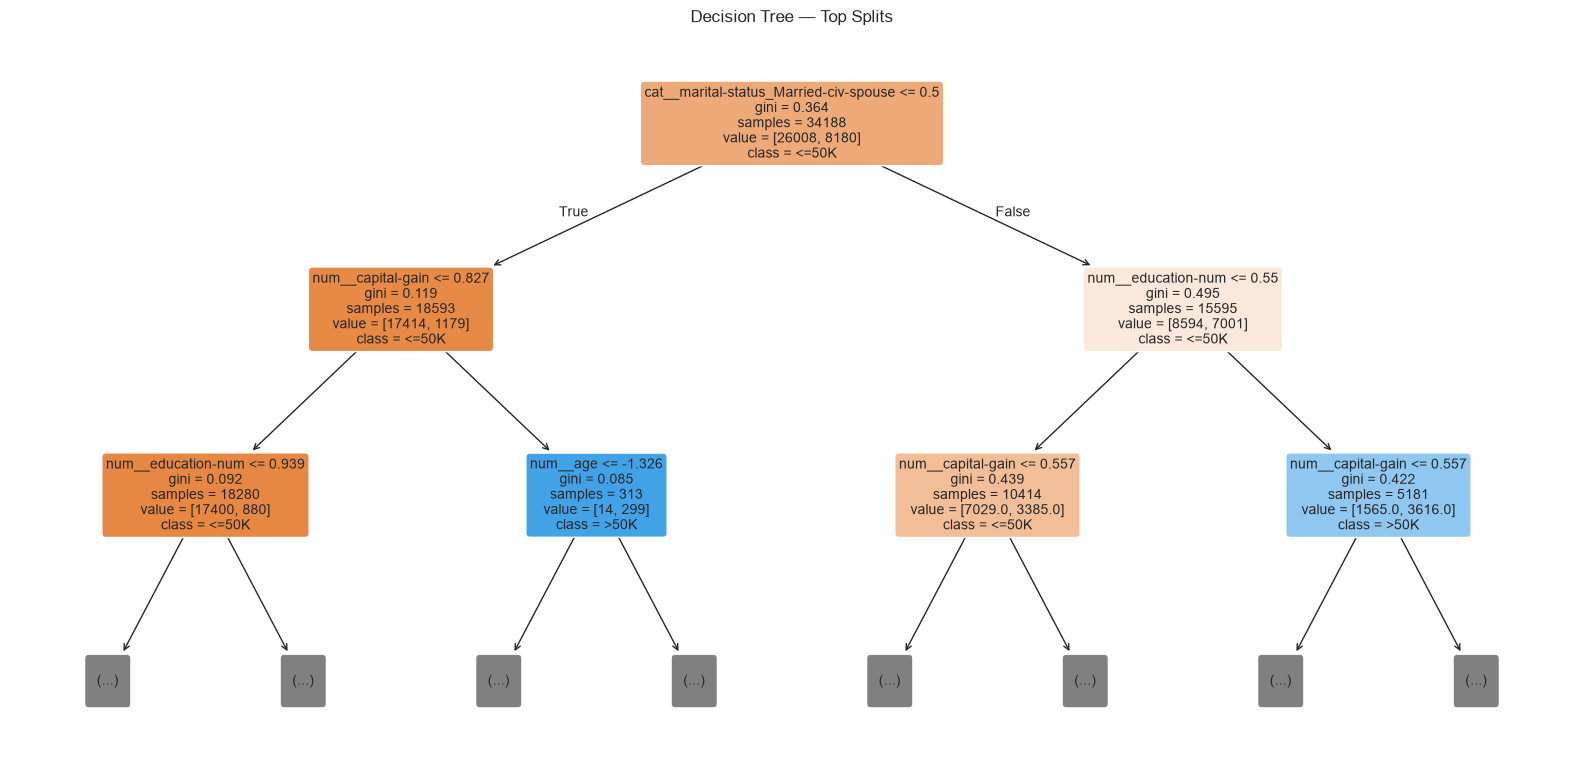

In [ ]:
tree_feature_names = decision_tree_pipeline.named_steps['preprocessor'].get_feature_names_out()

fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(
    tree_clf,
    max_depth=2,
    feature_names=tree_feature_names,
    class_names=["<=50K", ">50K"],
    filled=True,
    rounded=True,
    fontsize=12,
    ax=ax,
)
plt.title("Decision Tree")
plt.tight_layout()
plt.show()

### Top 3 splits

**Depth:** capped at 5. **Train accuracy 0.8519, test accuracy 0.8538**, a gap of ~0.0020, indicating the depth cap is controlling overfitting effectively; the tree generalizes rather than memorizes.

**Top 3 splits:**
1. **Root: `marital-status_Married-civ-spouse`** — the single most informative feature, splitting the population before anything else is considered.
2. **Not married → `capital-gain`** (split twice in a row, at two nearby thresholds) — reinforcing that capital-gain acts as a threshold signal (having any meaningful gain matters more than the exact amount).
3. **Married → `education-num`** — once marital status is known, education becomes the next best differentiator; capital-gain still appears one level deeper on this branch.

**Sensible?** Yes. The same top features appear in both the tree and the Logistic Regression model: marital status, capital gain, and education level. When two different models agree on the top signals, it makes them more likely to be real rather than just quirks of one algorithm.


Both models cleared yesterday's rule-based baseline on the metric that matters, precision = 0.4852, by a wide margin: Logistic Regression reached 0.7399 and Decision Tree reached 0.7658. This precision gain came with some recall cost: Logistic Regression's recall (0.5937) sits very close to the rule baseline's recall (0.5967), essentially the same coverage, just 0.0030 lower. Decision Tree's recall (0.5607) is meaningfully below the baseline, a drop of 0.0360, meaning it is trading more coverage for its precision advantage. This trade-off is worth watching, not just the precision headline number, since our Day 1 framing explicitly cared about not retreating into an overly conservative, low-coverage prediction pattern.

Logistic Regression is the interpretable, production-friendly candidate; its coefficients map directly onto yesterday's error analysis (education, capital gains, marital status, occupation). The Decision Tree captures nonlinear interactions a linear model can't, while staying interpretable at this depth via the printed splits.


In [ ]:
import joblib

joblib.dump(preprocessor, "Models/day2_preprocessor.joblib")
joblib.dump(logistic_pipeline, "Models/day2_logistic_pipeline.joblib")
joblib.dump(decision_tree_pipeline, "Models/day2_decision_tree_pipeline.joblib")
print("Saved reusable pipeline + fitted models to Models/ for Next Day.")

Saved reusable pipeline + fitted models to Models/ for Next Day.
